# Haar Cascade Face Detection - Complete Explanation

## What We're Building
A face detection system that finds faces and eyes in images using **Viola-Jones Algorithm** (Haar Cascades)

---

## Overview of the Algorithm

### Why Haar Cascades?
- **Fast**: Real-time performance on low-end hardware
- **Accurate**: Pre-trained on thousands of images
- **Cascade Structure**: Rejects background quickly, focuses on likely faces

### High-Level Flow
```
Image → Grayscale → Sliding Window → Haar Features → Cascade → Detected Boxes
```


In [2]:
!pip install opencv-python -q

## Step 1: Import Libraries & Upload Image

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow  # Special Colab display function

# Upload image
print("\n📸 Upload an image with faces:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"✅ Loaded: {filename}")


📸 Upload an image with faces:


Saving woman-stands-with-her-coworkers-professional-network.webp to woman-stands-with-her-coworkers-professional-network.webp
✅ Loaded: woman-stands-with-her-coworkers-professional-network.webp


## Step 2: Load Pre-trained Cascade Classifiers

### Why Cascades?
OpenCV provides **pre-trained Haar Cascades** - they're already trained on millions of face/eye images

### Available Cascades
| Cascade File | Detects | Use Case |
|---|---|---|
| `haarcascade_frontalface_default.xml` | Front-facing faces | Most common |
| `haarcascade_frontalface_alt.xml` | Alternative front-facing | Different angles |
| `haarcascade_profileface.xml` | Side profile faces | Lateral views |
| `haarcascade_eye.xml` | Eyes | Sub-detection in faces |
| `haarcascade_smile.xml` | Smiles | Emotional detection |
| `haarcascade_fullbody.xml` | Full human body | Crowd detection |


In [4]:
# Load pre-trained cascades (trained on thousands of images)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

print("✅ Cascades loaded successfully")

✅ Cascades loaded successfully


## Step 3: Load and Convert Image to Grayscale

### Why Grayscale? 🖤
1. **Computational Efficiency**: Grayscale = 1 channel, Color = 3 channels (BGR). Processes 3x faster
2. **Haar Features Orientation**: Haar features (lines, edges) are based on **intensity differences**, not color
   - A face has the same edge patterns regardless of color
   - Eye→cheek boundary exists in grayscale
3. **Training**: Cascades were trained on grayscale data
4. **Reduces Noise**: Color variations (lighting, clothing) don't affect edge detection

### What Gets Lost?
- **Skin tone info** → But edges still visible
- **Hair color** → But still detected as dark region
- **Clothing** → Doesn't matter for face detection

### Visual Example
```
Color (BGR):     Grayscale:
R=255 G=200      G=220 (average weighted)
R=100 G=150      G=125
```


Original shape: (700, 1245, 3) (Height, Width, Channels)
Grayscale shape: (700, 1245) (Height, Width only)
Size reduction: 3.0x


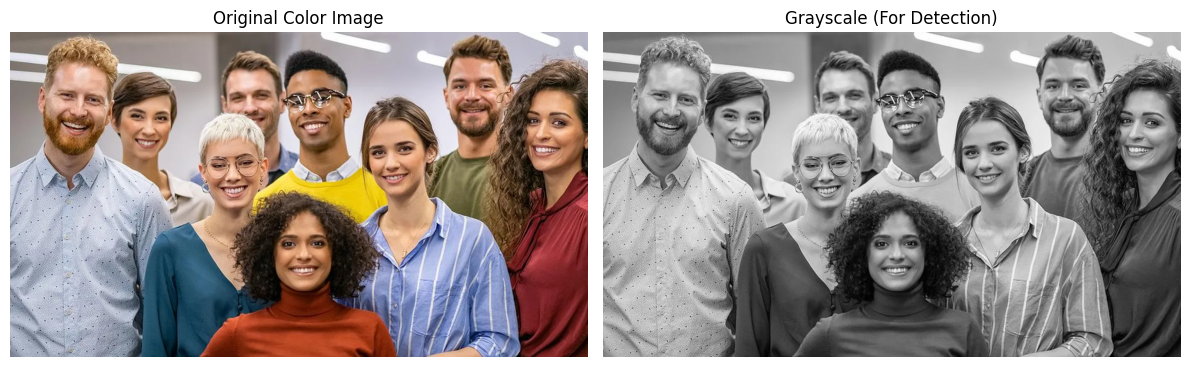

In [5]:
# Load original image
img = cv2.imread(filename)

# CRITICAL: Convert to grayscale
# OpenCV reads as BGR by default
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(f"Original shape: {img.shape} (Height, Width, Channels)")
print(f"Grayscale shape: {gray.shape} (Height, Width only)")
print(f"Size reduction: {img.nbytes / gray.nbytes:.1f}x")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Color Image')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale (For Detection)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Step 4: Understanding Haar Features & Sliding Windows

### What Are Haar Features? 📊
Simple **vertical and horizontal line patterns** that detect edges:

```
VERTICAL Feature:          HORIZONTAL Feature:
┌─────┐                    ┌──────────┐
│ ■ │ ░ │  = Dark│Light   │ ■ ■ ■ ■ │ = Dark
│ ■ │ ░ │                 │ ░ ░ ░ ░ │ = Light
└─────┘                    └──────────┘

Feature Value = SUM(Dark pixels) - SUM(Light pixels)
If Value > Threshold → Likely a face edge
```

### Why Vertical AND Horizontal?
- **Vertical**: Detects eye-to-eye edges (horizontal line across eyes)
- **Horizontal**: Detects face boundary (vertical lines on face sides)
- **Diagonal**: Captures nose, cheekbones
- **All Combined**: Complete face pattern recognition

### Sliding Window Mechanism 🪟
```
Step 1: Start at top-left, evaluate all Haar features
        [Window] ─→ Pass cascade? YES → Likely face
                                    NO → Skip

Step 2: Move right by 1 pixel, repeat
        ─→ [Window] ─→ Check again

Step 3: Move down by 1 pixel, repeat from left
        [Window] ─→ [Window] ─→ ... ─→ next row
        ↓
        [Window] ─→ [Window] ─→ ...

Step 4: Scale the window UP (1.1x, 1.2x, 1.3x) and repeat entire process
        (Detects faces of different sizes)
```

### Parameters Explained
| Parameter | Value | Meaning |
|---|---|---|
| `scaleFactor` | 1.1 | Each scale = previous × 1.1 (10% increase) |
| `minNeighbors` | 5 | Requires 5+ overlapping windows to confirm face |
| `minSize` | (30,30) | Ignore detections smaller than 30×30 pixels |
| `maxSize` | (400,400) | Ignore detections larger than this |



In [6]:
# CORE DETECTION: Sliding Window + Cascade
print("🔍 Detecting faces...")
print("   → Using VERTICAL and HORIZONTAL Haar features")
print("   → Sliding window across image at multiple scales")
print()

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,      # 10% scale increase per iteration
    minNeighbors=5,       # Need 5+ overlapping detections to confirm
    minSize=(30, 30),     # Minimum face size
    maxSize=(400, 400)    # Maximum face size
)

print(f"✅ FOUND {len(faces)} face(s)!")
print()
for i, (x, y, w, h) in enumerate(faces, 1):
    print(f"   Face {i}: Position({x}, {y}) Size({w}×{h} pixels)")

🔍 Detecting faces...
   → Using VERTICAL and HORIZONTAL Haar features
   → Sliding window across image at multiple scales

✅ FOUND 10 face(s)!

   Face 1: Position(923, 58) Size(147×147 pixels)
   Face 2: Position(69, 79) Size(162×162 pixels)
   Face 3: Position(569, 79) Size(159×159 pixels)
   Face 4: Position(452, 85) Size(136×136 pixels)
   Face 5: Position(226, 127) Size(146×146 pixels)
   Face 6: Position(1080, 133) Size(153×153 pixels)
   Face 7: Position(740, 190) Size(167×167 pixels)
   Face 8: Position(404, 229) Size(143×143 pixels)
   Face 9: Position(559, 397) Size(147×147 pixels)
   Face 10: Position(769, 446) Size(134×134 pixels)


## Step 5: Drawing Boxes - Color Choices Explained 🎨

### Why Blue for Faces? 💙
- **Default OpenCV convention**: BGR color space (not RGB!)
- Blue = (255, 0, 0) in BGR = High visibility on most skin tones
- Psychological: Blue = reliable, confidence

### Why GREEN for Eyes? 💚
- **High contrast** against skin and eyes
- **Visibility**: Easy to spot in images
- **Convention**: Green = secondary detection (sub-region of face)
- **Psychology**: Green = verified, second-pass success

### Why NOT Red?
- Red (0, 0, 255) can blend with skin tones in certain lighting
- Less distinguishable from background

### OpenCV BGR Color Reference
```
Black    = (0, 0, 0)
Blue     = (255, 0, 0)     ← Face (strong, reliable)
Green    = (0, 255, 0)     ← Eyes (secondary, accurate)
Red      = (0, 0, 255)     ← Avoid (confusing with skin)
Yellow   = (0, 255, 255)
Cyan     = (255, 255, 0)
Magenta  = (255, 0, 255)
White    = (255, 255, 255)
```

### Why Line Thickness = 2?
- **Thick enough** to see clearly
- **Not too thick** to obscure image
- Standard for annotation


In [7]:
# Create a copy to annotate
result = img.copy()

print("🎨 Drawing boxes...")

# Loop through detected faces
for face_idx, (x, y, w, h) in enumerate(faces, 1):
    # Draw BLUE rectangle around face
    # (255, 0, 0) = Blue in BGR format
    cv2.rectangle(result, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # Add label
    cv2.putText(result, f"Face {face_idx}", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # NESTED DETECTION: Now detect eyes WITHIN each face
    # Extract the face region only
    roi_gray = gray[y:y+h, x:x+w]      # Gray face region
    roi_color = result[y:y+h, x:x+w]   # Color face region for annotation

    # Run eye cascade only on face region (much faster + accurate)
    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.05,
        minNeighbors=4,
        minSize=(15, 15)
    )

    print(f"   Face {face_idx}: Found {len(eyes)} eye(s)")

    # Draw GREEN rectangles around eyes
    # (0, 255, 0) = Green in BGR format
    for eye_idx, (ex, ey, ew, eh) in enumerate(eyes, 1):
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
        cv2.putText(roi_color, f"E{eye_idx}", (ex, ey-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)

print(f"✅ Drawing complete!")

🎨 Drawing boxes...
   Face 1: Found 2 eye(s)
   Face 2: Found 2 eye(s)
   Face 3: Found 2 eye(s)
   Face 4: Found 2 eye(s)
   Face 5: Found 2 eye(s)
   Face 6: Found 2 eye(s)
   Face 7: Found 3 eye(s)
   Face 8: Found 3 eye(s)
   Face 9: Found 4 eye(s)
   Face 10: Found 0 eye(s)
✅ Drawing complete!


## Step 6: Why Blend? (Overlaying Annotations)

### The Blending Concept
When you draw rectangles on an image, you have options:

1. **Hard Overwrite** (current approach)
   ```
   result[y:y+h, x:x+w] = rectangle_pixels  # Replaces original
   Pros: Clear, high contrast
   Cons: Loses image info beneath box
   ```

2. **Alpha Blending** (overlay effect)
   ```
   output = (1 - alpha) × original + alpha × overlay
   Pros: Preserves image visibility
   Cons: Boxes less visible
   ```

### When to Use Blending?
- **Video processing**: Annotate without hiding faces
- **Analysis**: Show detection + keep original visible
- **Presentation**: Less harsh appearance


In [8]:
# Optional: Create BLENDED version (translucent boxes)
print("\n🎬 Creating blended annotation...")

result_blended = img.copy()
alpha = 0.3  # 30% box, 70% original image

for (x, y, w, h) in faces:
    overlay = result_blended.copy()
    # Draw thick box on overlay
    cv2.rectangle(overlay, (x, y), (x+w, y+h), (255, 0, 0), 3)
    # Blend: overlay takes 30%, original takes 70%
    result_blended = cv2.addWeighted(overlay, alpha, result_blended, 1-alpha, 0)

print("✅ Blended version ready")


🎬 Creating blended annotation...
✅ Blended version ready


## Step 7: Display Results


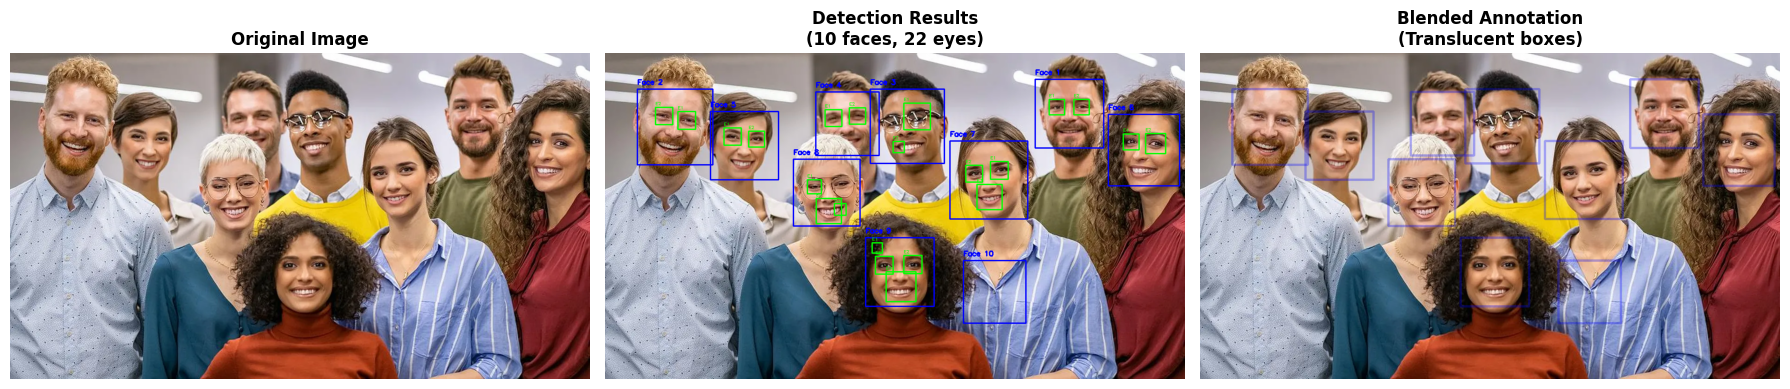

✅ All visualizations displayed!


In [9]:
# Display all versions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Hard boxes (current)
axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Detection Results\n({len(faces)} faces, {sum(len(eye_cascade.detectMultiScale(gray[y:y+h, x:x+w], 1.05, 4, minSize=(15,15))) for x,y,w,h in faces)} eyes)', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Blended boxes
axes[2].imshow(cv2.cvtColor(result_blended, cv2.COLOR_BGR2RGB))
axes[2].set_title('Blended Annotation\n(Translucent boxes)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('detection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ All visualizations displayed!")

## Step 8: Complete Reference - Cascade Classifiers


In [11]:
cascades_reference = {
    'haarcascade_frontalface_default.xml': {
        'detects': 'Front-facing faces',
        'angles': '0-30°',
        'use_case': 'Most common - photos, webcam feeds',
        'accuracy': 'High'
    },
    'haarcascade_frontalface_alt.xml': {
        'detects': 'Alternative front faces',
        'angles': '0-45°',
        'use_case': 'Different face shapes, slight tilts',
        'accuracy': 'Medium-High'
    },
    'haarcascade_profileface.xml': {
        'detects': 'Side-profile faces',
        'angles': '90°',
        'use_case': 'Crowd monitoring, side views',
        'accuracy': 'Medium'
    },
    'haarcascade_eye.xml': {
        'detects': 'Eyes',
        'angles': 'Any',
        'use_case': 'Sub-detection within faces (nested)',
        'accuracy': 'High in faces'
    },
    'haarcascade_smile.xml': {
        'detects': 'Smiles',
        'angles': '0-30°',
        'use_case': 'Emotion detection, happy photos',
        'accuracy': 'Medium'
    },
    'haarcascade_fullbody.xml': {
        'detects': 'Full human body',
        'angles': 'Front',
        'use_case': 'Crowd detection, security',
        'accuracy': 'Medium'
    }
}

print("\n" + "="*80)
print("AVAILABLE CASCADE CLASSIFIERS REFERENCE")
print("="*80)

for cascade_name, info in cascades_reference.items():
    print(f"\n📋 {cascade_name}")
    print(f"   Detects: {info['detects']}")
    print(f"   Angles: {info['angles']}")
    print(f"   Use Case: {info['use_case']}")
    print(f"   Accuracy: {info['accuracy']}")


AVAILABLE CASCADE CLASSIFIERS REFERENCE

📋 haarcascade_frontalface_default.xml
   Detects: Front-facing faces
   Angles: 0-30°
   Use Case: Most common - photos, webcam feeds
   Accuracy: High

📋 haarcascade_frontalface_alt.xml
   Detects: Alternative front faces
   Angles: 0-45°
   Use Case: Different face shapes, slight tilts
   Accuracy: Medium-High

📋 haarcascade_profileface.xml
   Detects: Side-profile faces
   Angles: 90°
   Use Case: Crowd monitoring, side views
   Accuracy: Medium

📋 haarcascade_eye.xml
   Detects: Eyes
   Angles: Any
   Use Case: Sub-detection within faces (nested)
   Accuracy: High in faces

📋 haarcascade_smile.xml
   Detects: Smiles
   Angles: 0-30°
   Use Case: Emotion detection, happy photos
   Accuracy: Medium

📋 haarcascade_fullbody.xml
   Detects: Full human body
   Angles: Front
   Use Case: Crowd detection, security
   Accuracy: Medium


## Summary: Why Everything Is Included

| Component | Why It's Needed |
|---|---|
| **Grayscale** | Haar features detect edges → edges are intensity-based, not color-based |
| **Sliding Window** | Scans entire image systematically |
| **Multiple Scales** | Detects faces of different sizes |
| **Vertical Features** | Detects horizontal edges (eyes, mouth) |
| **Horizontal Features** | Detects vertical edges (face sides, nose) |
| **minNeighbors** | Removes false positives by requiring consensus |
| **Blue Boxes** | High contrast, convention, psychology |
| **Green Boxes** | Secondary detection indicator, high contrast |
| **Blending** | Optional - preserves image detail under annotations |
| **Nested Detection** | Eyes searched ONLY in face region (faster, more accurate) |

---

## Advanced Improvements (Optional)

```python
# 1. Multiple cascade combinations
faces_alt = face_cascade_alt.detectMultiScale(gray, 1.05, 3)
# Average results for better accuracy

# 2. Adaptive histogram equalization (improves detection in dark images)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray_enhanced = clahe.apply(gray)

# 3. Multi-threaded detection
# Use parallel processing for large images

# 4. Deep Learning Alternative
# Use YOLOv8, SSD, or RetinaFace for better accuracy
```
